# Deep-Learning Inverse Design of Metasurface Phase Profiles

**Task.** Given a desired **2D energy (intensity) map** and the **distance** from the
metasurface to the plane where that energy map should appear, predict the metasurface's
**phase-shift profile** — in a single forward pass.

**How it is trained.** The network's predicted phase profile is fed to a *differentiable*
angular-spectrum propagator, which computes the energy map that the profile actually
produces at the requested distance. The loss compares that propagated energy map with the
desired one, so the network learns physics-consistent phase profiles **without ever seeing
a ground-truth phase label** (there is no unique one — the problem is many-to-one).

**Data.** The desired energy maps are **MNIST digits**: the **MNIST training split** supplies
the training targets and the **MNIST test split** supplies the held-out evaluation targets.
Every target is paired with a focal distance drawn from the working range.

**Analysis.** The learned one-shot designer is compared against the classical iterative
**Gerchberg–Saxton (GS)** and **weighted Gerchberg–Saxton (WGS)** phase-retrieval algorithms,
on shape fidelity (correlation, PSNR, RMSE), diffraction efficiency, and runtime.

---
Notebook layout: each stage is split into a **definitions** cell (functions/classes), an
**execution** cell (runs the stage), and a **visualization/print** cell, so stages can be
re-run in isolation.

## 1. Imports and physical configuration

The system operates at 150 GHz (2 mm wavelength). Two co-pitched grids are used: the
**aperture grid** is the physical metasurface (and the grid the predicted phase lives on);
the **observation grid** is the plane where the target energy map is defined. Here they are
the same size, but the propagator supports them differing.

In [1]:
# ── DEFINITIONS: imports, RNG seeds, CUDA-complex device selection ────────────
import os, glob, ctypes, time, math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

RANDOM_SEED = 0
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)


def _preload_nvrtc_builtins():
    """RTX 5090 / torch-cu13: preload libnvrtc-builtins by absolute path so the
    JIT complex-kernel dlopen-by-soname (abs/angle/exp on complex) resolves."""
    cuda_major = (torch.version.cuda or "").split(".")[0]
    if not cuda_major:
        return
    nvidia_dir = os.path.join(os.path.dirname(torch.__file__), "..", "nvidia")
    pattern = os.path.join(nvidia_dir, "**", f"libnvrtc-builtins.so.{cuda_major}*")
    for shared_object in glob.glob(pattern, recursive=True):
        try:
            ctypes.CDLL(shared_object, mode=ctypes.RTLD_GLOBAL)
            return
        except OSError:
            continue


def select_complex_capable_device():
    """Return 'cuda' only if complex elementwise kernels actually run, else 'cpu'."""
    if torch.cuda.is_available():
        _preload_nvrtc_builtins()
        try:
            probe = torch.zeros(1, 1, 2, 2, device="cuda")
            field = torch.complex(torch.cos(probe), torch.sin(probe))
            round_trip = torch.fft.ifft2(torch.fft.fft2(field) * field)
            _ = round_trip.abs().sum().item()
            _ = torch.angle(round_trip).sum().item()
            return "cuda"
        except Exception as error:
            print(f"[info] CUDA complex ops unavailable ({type(error).__name__}); using CPU.")
    return "cpu"


def complex_exp_from_phase(phase):
    """e^{i·phase} = cos(phase) + i·sin(phase)."""
    return torch.complex(torch.cos(phase), torch.sin(phase))

In [2]:
# ── DEFINITIONS: the physical / numerical configuration ──────────────────────
class MetasurfaceConfig:
    speed_of_light_m_per_s   = 3e8
    frequency_hz             = 150e9
    wavelength_m             = speed_of_light_m_per_s / frequency_hz   # 2 mm
    element_pitch_m          = wavelength_m / 2                        # sub-wavelength spacing

    aperture_grid_size       = 128        # metasurface = predicted-phase grid (N_a × N_a)
    observation_grid_size    = 128        # plane where the target energy map is defined
    asm_zero_pad_factor      = 2          # anti-aliasing guard band for the propagator

    focal_distance_min_m     = 0.20       # focal distance is a MODEL INPUT, sampled in this range
    focal_distance_max_m     = 1.20
    reference_focal_distance_m = 0.60     # distance used for single-example demos

    num_discrete_phase_levels = 8         # fabricable phase states (K); K-level quantization

TRAINING_STEPS      = 5000
BATCH_SIZE          = 16
LEARNING_RATE       = 2e-4
WEIGHT_DECAY        = 1e-5
USE_QUANTIZATION_AWARE_TRAINING = True

CONFIG = MetasurfaceConfig()
CONFIG.device                 = select_complex_capable_device()
CONFIG.element_pitch_m        = CONFIG.element_pitch_m
CONFIG.aperture_extent_m      = CONFIG.aperture_grid_size    * CONFIG.element_pitch_m
CONFIG.observation_extent_m   = CONFIG.observation_grid_size * CONFIG.element_pitch_m


def minimum_feature_size_m(focal_distance_m):
    """Diffraction-limited resolution at a plane (band-limit λ·z / aperture)."""
    return CONFIG.wavelength_m * focal_distance_m / CONFIG.aperture_extent_m


def normalize_focal_distance(focal_distance_m):
    """Map a focal distance (m) into [0, 1] for conditioning the network."""
    span = CONFIG.focal_distance_max_m - CONFIG.focal_distance_min_m
    return (focal_distance_m - CONFIG.focal_distance_min_m) / span

In [3]:
# ── EXECUTION + PRINT: report the configuration ──────────────────────────────
print(f"Device                : {CONFIG.device}")
print(f"Frequency / wavelength : {CONFIG.frequency_hz/1e9:.0f} GHz / {CONFIG.wavelength_m*1e3:.2f} mm")
print(f"Element pitch          : {CONFIG.element_pitch_m*1e3:.2f} mm")
print(f"Aperture (metasurface) : {CONFIG.aperture_grid_size}×{CONFIG.aperture_grid_size} elements "
      f"= {CONFIG.aperture_extent_m*100:.2f} cm")
print(f"Observation plane      : {CONFIG.observation_grid_size}×{CONFIG.observation_grid_size} grid "
      f"= {CONFIG.observation_extent_m*100:.2f} cm")
print(f"Focal-distance range   : {CONFIG.focal_distance_min_m*100:.0f}–{CONFIG.focal_distance_max_m*100:.0f} cm "
      f"(a model input)")
print(f"Discrete phase levels  : K = {CONFIG.num_discrete_phase_levels}")
print(f"Min feature size       : {minimum_feature_size_m(CONFIG.focal_distance_min_m)*1e3:.2f} mm "
      f"@{CONFIG.focal_distance_min_m*100:.0f} cm  …  "
      f"{minimum_feature_size_m(CONFIG.focal_distance_max_m)*1e3:.2f} mm "
      f"@{CONFIG.focal_distance_max_m*100:.0f} cm")

Device                : cuda
Frequency / wavelength : 150 GHz / 2.00 mm
Element pitch          : 1.00 mm
Aperture (metasurface) : 128×128 elements = 12.80 cm
Observation plane      : 128×128 grid = 12.80 cm
Focal-distance range   : 20–120 cm (a model input)
Discrete phase levels  : K = 8
Min feature size       : 3.12 mm @20 cm  …  18.75 mm @120 cm


## 2. Differentiable angular-spectrum propagator

The forward physics. Given a complex field on the aperture and a distance, the
band-limited angular-spectrum method (ASM) returns the field at the observation plane.
It is fully differentiable (implemented with `torch.fft`), so gradients of the observed
energy map flow back to the phase profile — this is what makes end-to-end training possible.
The `distance` argument may be a scalar or a per-sample tensor (each item in a batch can
be designed for its own focal distance).

In [4]:
# ── DEFINITIONS: the propagator and phase→energy-map forward model ────────────
def angular_spectrum_propagate(input_field, distance_m, pitch_m, wavelength_m,
                               zero_pad_factor=2, output_grid_size=None):
    """Propagate a complex field [B,1,N,N] by `distance_m` with the band-limited
    angular-spectrum method; return the central `output_grid_size` samples.
    `distance_m` may be a python float or a tensor broadcastable to [B,1,1,1]."""
    batch, _, grid_size, _ = input_field.shape
    output_grid_size = grid_size if output_grid_size is None else output_grid_size
    compute_grid = max(grid_size, output_grid_size) * zero_pad_factor
    pad_low = (compute_grid - grid_size) // 2
    padded_field = F.pad(input_field, (pad_low, compute_grid - grid_size - pad_low,
                                       pad_low, compute_grid - grid_size - pad_low))

    spatial_freq = torch.fft.fftfreq(compute_grid, d=pitch_m,
                                     device=input_field.device, dtype=torch.float32)
    freq_x, freq_y = torch.meshgrid(spatial_freq, spatial_freq, indexing="ij")
    wavenumber = 2 * np.pi / wavelength_m
    propagating_arg = 1.0 - (wavelength_m * freq_x) ** 2 - (wavelength_m * freq_y) ** 2
    is_propagating = propagating_arg > 0                         # discard evanescent waves
    sqrt_arg = torch.sqrt(torch.clamp(propagating_arg, min=0.0))
    freq_step = 1.0 / (compute_grid * pitch_m)

    if torch.is_tensor(distance_m):
        distance = distance_m.reshape(-1, 1, 1, 1).to(input_field.device, torch.float32)
        band_limit = 1.0 / (wavelength_m * torch.sqrt((2 * freq_step * distance.abs()) ** 2 + 1))
        in_band = (freq_x.abs()[None, None] < band_limit) & (freq_y.abs()[None, None] < band_limit)
        transfer_phase = (wavenumber * distance) * sqrt_arg[None, None]
        transfer_function = torch.where(is_propagating[None, None] & in_band,
                                        complex_exp_from_phase(transfer_phase),
                                        torch.zeros((), dtype=torch.complex64, device=input_field.device))
    else:
        band_limit = 1.0 / (wavelength_m * np.sqrt((2 * freq_step * abs(distance_m)) ** 2 + 1))
        in_band = (freq_x.abs() < band_limit) & (freq_y.abs() < band_limit)
        transfer_phase = (wavenumber * distance_m) * sqrt_arg
        transfer_function = torch.where(is_propagating & in_band,
                                        complex_exp_from_phase(transfer_phase),
                                        torch.zeros((), dtype=torch.complex64, device=input_field.device))

    propagated = torch.fft.ifft2(torch.fft.fft2(padded_field) * transfer_function)
    crop = (compute_grid - output_grid_size) // 2
    return propagated[..., crop:crop + output_grid_size, crop:crop + output_grid_size]


def intensity_of_field(complex_field):
    """|U|² — the energy (intensity) map of a complex field."""
    return complex_field.real ** 2 + complex_field.imag ** 2


def energy_map_from_phase_profile(phase_profile, distance_m, output_grid_size=None):
    """Phase profile [B,1,N_a,N_a] on the aperture → energy map [B,1,N_o,N_o] at the
    observation plane. Every aperture element radiates (unit amplitude); nothing masked."""
    output_grid_size = CONFIG.observation_grid_size if output_grid_size is None else output_grid_size
    aperture_field = complex_exp_from_phase(phase_profile.to(torch.float32))
    observed_field = angular_spectrum_propagate(
        aperture_field, distance_m, CONFIG.element_pitch_m, CONFIG.wavelength_m,
        CONFIG.asm_zero_pad_factor, output_grid_size=output_grid_size)
    return intensity_of_field(observed_field)


def draw_aperture_outline(axis, color="cyan", linewidth=1.2):
    """Overlay the physical aperture boundary on an observation-plane image."""
    half_extent_cm = CONFIG.aperture_extent_m / 2 * 100
    axis.add_patch(plt.Rectangle((-half_extent_cm, -half_extent_cm),
                                 2 * half_extent_cm, 2 * half_extent_cm,
                                 fill=False, ls="--", ec=color, lw=linewidth))

In [5]:
# ── EXECUTION: sanity-check the propagator with an analytic focusing lens ─────
# A converging (Fermat) phase profile must focus a plane wave to a tight central spot.
_aperture_coords_m = (torch.arange(CONFIG.aperture_grid_size)
                      - (CONFIG.aperture_grid_size - 1) / 2) * CONFIG.element_pitch_m
_grid_x_m, _grid_y_m = torch.meshgrid(_aperture_coords_m, _aperture_coords_m, indexing="ij")
_radius_m = torch.sqrt(_grid_x_m ** 2 + _grid_y_m ** 2 + CONFIG.reference_focal_distance_m ** 2)
# minus sign matches the ASM's exp(+ikz) convention (converging lens)
focusing_phase_profile = ((-2 * np.pi / CONFIG.wavelength_m)
                          * (_radius_m - _radius_m.min())) % (2 * np.pi)

focused_energy_map = energy_map_from_phase_profile(
    focusing_phase_profile[None, None].to(CONFIG.device),
    CONFIG.reference_focal_distance_m).squeeze().cpu().numpy()

peak_to_mean_ratio = float(focused_energy_map.max() / focused_energy_map.mean())
_center = CONFIG.observation_grid_size // 2
central_energy_fraction = (focused_energy_map[_center-2:_center+3, _center-2:_center+3].sum()
                           / focused_energy_map.sum())
assert peak_to_mean_ratio > 20, f"Propagator not focusing (PMR={peak_to_mean_ratio:.1f})"

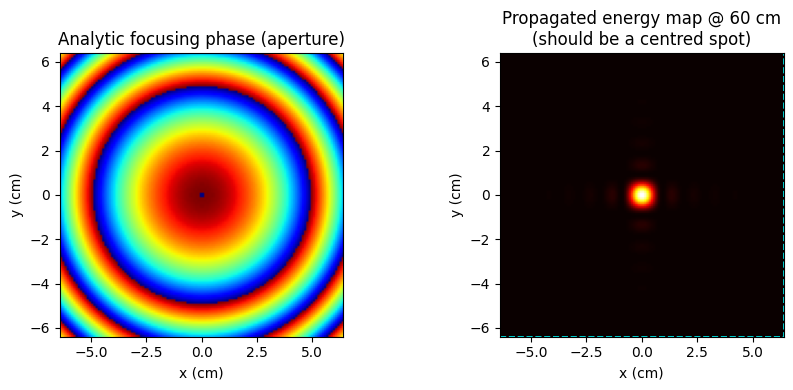

Peak-to-mean ratio : 183
Central-5×5 energy : 24.3%
Propagator OK — a focusing phase yields a centred spot.


In [6]:
# ── VISUALIZATION + PRINT: focusing sanity check ─────────────────────────────
_aperture_extent_cm = np.array([-1, 1, -1, 1]) * CONFIG.aperture_extent_m / 2 * 100
_observation_extent_cm = np.array([-1, 1, -1, 1]) * CONFIG.observation_extent_m / 2 * 100

figure, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].imshow(focusing_phase_profile.cpu(), cmap="jet",
               extent=_aperture_extent_cm, origin="lower")
axes[0].set_title("Analytic focusing phase (aperture)")
axes[0].set_xlabel("x (cm)"); axes[0].set_ylabel("y (cm)")
axes[1].imshow(focused_energy_map, cmap="hot", extent=_observation_extent_cm, origin="lower")
axes[1].set_title(f"Propagated energy map @ {CONFIG.reference_focal_distance_m*100:.0f} cm\n"
                  "(should be a centred spot)")
axes[1].set_xlabel("x (cm)"); axes[1].set_ylabel("y (cm)")
draw_aperture_outline(axes[1])
plt.tight_layout(); plt.show()

print(f"Peak-to-mean ratio : {peak_to_mean_ratio:,.0f}")
print(f"Central-5×5 energy : {central_energy_fraction*100:.1f}%")
print("Propagator OK — a focusing phase yields a centred spot.")

## 3. Discrete phase levels (quantization-aware)

A fabricated metasurface realises only `K` discrete phase states. Training is
**quantization-aware**: the phase is snapped to the K-level grid *inside* the forward pass
using a straight-through estimator (forward = quantized value, backward = identity gradient),
so the loss is computed on the profile that would actually be manufactured.

In [7]:
# ── DEFINITIONS: K-level quantizer with a straight-through estimator ──────────
def phase_quantization_levels(num_levels, device=None):
    """The K allowed phase values, evenly spaced on (-π, π]."""
    levels = torch.arange(num_levels, device=device, dtype=torch.float32) * (2 * np.pi / num_levels)
    return torch.remainder(levels + np.pi, 2 * np.pi) - np.pi


def quantize_phase_profile(phase_profile, num_levels=None):
    """Snap each phase to the nearest of K circular levels; identity gradient (STE)."""
    num_levels = CONFIG.num_discrete_phase_levels if num_levels is None else num_levels
    levels = phase_quantization_levels(num_levels, phase_profile.device)
    circular_distance = phase_profile.unsqueeze(-1) - levels
    circular_distance = torch.remainder(circular_distance + np.pi, 2 * np.pi) - np.pi
    nearest_level = levels[circular_distance.abs().argmin(-1)]
    return phase_profile + (nearest_level - phase_profile).detach()      # straight-through


def snap_to_levels_regularizer(phase_profile, num_levels=None):
    """Penalty minimised exactly on the K-level grid; stabilises low-K training."""
    num_levels = CONFIG.num_discrete_phase_levels if num_levels is None else num_levels
    return (1 - torch.cos(num_levels * phase_profile)).mean()

In [8]:
# ── PRINT: the discrete phase states in use ──────────────────────────────────
_levels_deg = np.round(np.degrees(
    phase_quantization_levels(CONFIG.num_discrete_phase_levels).cpu().numpy()), 1)
print(f"K = {CONFIG.num_discrete_phase_levels} discrete phase levels (degrees): {_levels_deg}")

K = 8 discrete phase levels (degrees): [   0.   45.   90.  135. -180. -135.  -90.  -45.]


## 4. MNIST digits as (energy map, distance) targets

Each MNIST digit becomes a **desired energy map**: the 28×28 digit is resized onto the
observation grid, low-pass filtered to the diffraction limit at its focal distance, and
normalised to unit total energy (phase-only optics conserves power). The **MNIST training
split** feeds the training stream; the **MNIST test split** provides the held-out set. Each
target is paired with a focal distance — random per sample during training, and fixed
(seeded) for every test target so evaluation is deterministic.

In [9]:
# ── DEFINITIONS: MNIST loading and digit→energy-map rendering ────────────────
import torchvision
from PIL import Image, ImageFilter

MNIST_ROOT = "../datasets/mnist_torchvision"

_mnist_train = torchvision.datasets.MNIST(MNIST_ROOT, train=True,  download=True)
_mnist_test  = torchvision.datasets.MNIST(MNIST_ROOT, train=False, download=True)
MNIST_TRAIN_IMAGES = _mnist_train.data.numpy()          # [60000, 28, 28] uint8
MNIST_TRAIN_LABELS = _mnist_train.targets.numpy()
MNIST_TEST_IMAGES  = _mnist_test.data.numpy()           # [10000, 28, 28] uint8
MNIST_TEST_LABELS  = _mnist_test.targets.numpy()

DIGIT_EXTENT_FRACTION = 0.92        # digit spans this fraction of the observation grid


def render_digit_as_energy_map(digit_image_28x28, focal_distance_m,
                               grid_size=None, digit_extent_fraction=DIGIT_EXTENT_FRACTION):
    """Rasterise an MNIST digit to a [grid,grid] unit-sum energy map, band-limited to
    the feature size achievable at `focal_distance_m`."""
    grid_size = CONFIG.observation_grid_size if grid_size is None else grid_size
    digit_side_px = int(round(grid_size * digit_extent_fraction))
    resized_digit = Image.fromarray(digit_image_28x28).resize(
        (digit_side_px, digit_side_px), Image.BILINEAR)
    canvas = Image.new("L", (grid_size, grid_size), 0)
    offset = (grid_size - digit_side_px) // 2
    canvas.paste(resized_digit, (offset, offset))
    # blur_radius_px = max(minimum_feature_size_m(focal_distance_m) / CONFIG.element_pitch_m / 2.0, 0.8)
    # canvas = canvas.filter(ImageFilter.GaussianBlur(radius=float(blur_radius_px)))
    energy_map = np.asarray(canvas, dtype=np.float32)
    total = energy_map.sum()
    return energy_map / total if total > 0 else energy_map


def sample_training_batch(batch_size, generator, device=None):
    """Random MNIST-train digits at random focal distances → (targets [B,1,N,N], distances [B])."""
    device = device or CONFIG.device
    image_indices = generator.integers(0, len(MNIST_TRAIN_IMAGES), batch_size)
    focal_distances = generator.uniform(CONFIG.focal_distance_min_m,
                                        CONFIG.focal_distance_max_m, batch_size)
    energy_maps = [render_digit_as_energy_map(MNIST_TRAIN_IMAGES[i], z)
                   for i, z in zip(image_indices, focal_distances)]
    targets = torch.from_numpy(np.stack(energy_maps)[:, None]).to(device)
    distances = torch.tensor(focal_distances, dtype=torch.float32, device=device)
    return targets, distances


def sample_test_set(generator, num_samples):
    """Seed-sample `num_samples` images from the MNIST test split (without replacement) and
    render each into a desired energy map paired with a fixed focal distance. The generator's
    seed makes the sampled subset fully reproducible.
    Returns (energy_maps [N,H,W], distances [N], labels [N])."""
    sampled_indices = np.sort(generator.choice(len(MNIST_TEST_IMAGES), size=num_samples, replace=False))
    focal_distances = generator.uniform(CONFIG.focal_distance_min_m,
                                        CONFIG.focal_distance_max_m, num_samples).astype(np.float32)
    energy_maps = np.stack([render_digit_as_energy_map(MNIST_TEST_IMAGES[idx], focal_distances[j])
                            for j, idx in enumerate(sampled_indices)]).astype(np.float32)
    return energy_maps, focal_distances, MNIST_TEST_LABELS[sampled_indices].astype(np.int64)

In [10]:
# ── EXECUTION: build the training RNG stream and render the FULL held-out test set ─
TRAINING_STREAM_RNG = np.random.default_rng(RANDOM_SEED)          # drives sample_training_batch
TEST_SET_RNG        = np.random.default_rng(20240107)

# A reproducible, seed-sampled subset of the MNIST test split is the held-out evaluation set.
NUM_TEST_SAMPLES = 500
TEST_ENERGY_MAPS, TEST_FOCAL_DISTANCES, TEST_DIGIT_LABELS = sample_test_set(TEST_SET_RNG, NUM_TEST_SAMPLES)

print(f"MNIST train images : {len(MNIST_TRAIN_IMAGES):,}   (training-target stream)")
print(f"Held-out test set  : {len(TEST_ENERGY_MAPS):,} MNIST-test energy maps "
      f"(seed-sampled from the {len(MNIST_TEST_IMAGES):,}-image test split, seed 20240107)")
print(f"Focal distances    : {TEST_FOCAL_DISTANCES.min()*100:.0f}–{TEST_FOCAL_DISTANCES.max()*100:.0f} cm "
      f"(fixed per test image)")
print(f"Per-digit counts   : " + ", ".join(f"{d}:{int((TEST_DIGIT_LABELS==d).sum())}" for d in range(10)))

MNIST train images : 60,000   (training-target stream)
Held-out test set  : 500 MNIST-test energy maps (seed-sampled from the 10,000-image test split, seed 20240107)
Focal distances    : 20–119 cm (fixed per test image)
Per-digit counts   : 0:57, 1:52, 2:47, 3:50, 4:48, 5:43, 6:54, 7:57, 8:45, 9:47


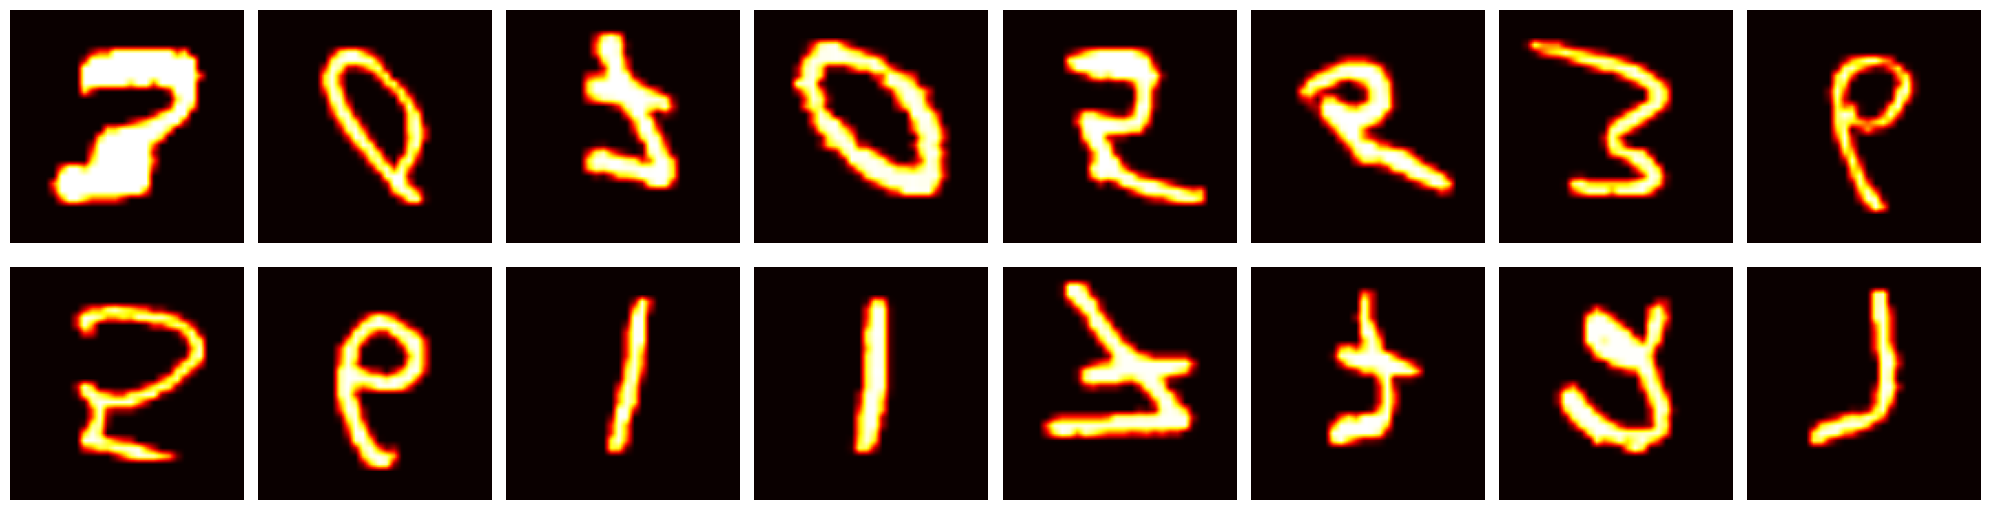

In [11]:
# ── VISUALIZATION: preview training-stream targets (top) and test targets (bottom) ─
_preview_extent_cm = np.array([-1, 1, -1, 1]) * CONFIG.observation_extent_m / 2 * 100
_preview_targets, _preview_distances = sample_training_batch(
    8, np.random.default_rng(1), device="cpu")

figure, axes = plt.subplots(2, 8, figsize=(20, 5.6))
for axis, energy_map, distance in zip(axes[0], _preview_targets, _preview_distances):
    axis.imshow(energy_map.squeeze(), cmap="hot", origin="lower", extent=_preview_extent_cm)
    # axis.set_title(f"train  z={distance*100:.0f}cm", fontsize=9)
    axis.axis("off")
for axis, index in zip(axes[1], range(8)):
    axis.imshow(TEST_ENERGY_MAPS[index], cmap="hot", origin="lower", extent=_preview_extent_cm)
    # axis.set_title(f"test '{TEST_DIGIT_LABELS[index]}'  z={TEST_FOCAL_DISTANCES[index]*100:.0f}cm", fontsize=9)
    axis.axis("off")
# plt.suptitle("Desired energy maps — MNIST train stream (top) vs held-out MNIST test set (bottom)", fontsize=13)
plt.tight_layout(); plt.show()

## 5. Inverse-design network: (energy map, distance) → phase profile

A distance-conditioned U-Net. The desired energy map is resampled onto the aperture grid;
the focal distance is injected two ways — as a constant input channel and, via FiLM
(feature-wise linear modulation), on the bottleneck. The output is a continuous phase in
(-π, π], later snapped to K levels. The final activation guarantees a valid phase range.

In [12]:
# ── DEFINITIONS: the phase-design U-Net and its training losses ──────────────
class DoubleConvBlock(nn.Module):
    """(Conv→BN→ReLU) × 2."""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1), nn.BatchNorm2d(out_channels), nn.ReLU(),
            nn.Conv2d(out_channels, out_channels, 3, padding=1), nn.BatchNorm2d(out_channels), nn.ReLU(),
        )
    def forward(self, x):
        return self.block(x)


class PhaseDesignUNet(nn.Module):
    """Maps (desired energy map [B,1,*,*], normalised focal distance [B]) → aperture phase
    profile [B,1,N_a,N_a]. Distance conditioning: a constant input plane + FiLM on the
    bottleneck from a small MLP of the distance."""
    def __init__(self, base_channels=48):
        super().__init__()
        c = base_channels
        self.input_block  = DoubleConvBlock(2, c)          # 2 channels: energy map + distance plane
        self.down_block_1 = DoubleConvBlock(c, c * 2)
        self.down_block_2 = DoubleConvBlock(c * 2, c * 4)
        self.bottleneck   = DoubleConvBlock(c * 4, c * 8)
        self.downsample   = nn.MaxPool2d(2)
        self.distance_film_mlp = nn.Sequential(               # → FiLM scale (γ) and shift (β)
            nn.Linear(1, 64), nn.ReLU(), nn.Linear(64, c * 8 * 2))
        self.upsample_2 = nn.ConvTranspose2d(c * 8, c * 4, 2, 2); self.up_block_2 = DoubleConvBlock(c * 8, c * 4)
        self.upsample_1 = nn.ConvTranspose2d(c * 4, c * 2, 2, 2); self.up_block_1 = DoubleConvBlock(c * 4, c * 2)
        self.upsample_0 = nn.ConvTranspose2d(c * 2, c,     2, 2); self.up_block_0 = DoubleConvBlock(c * 2, c)
        self.output_conv = nn.Conv2d(c, 1, 1)

    def forward(self, desired_energy_map, normalized_distance):
        batch = desired_energy_map.shape[0]
        aperture = CONFIG.aperture_grid_size
        if desired_energy_map.shape[-1] != aperture or desired_energy_map.shape[-2] != aperture:
            desired_energy_map = F.interpolate(desired_energy_map, size=(aperture, aperture),
                                               mode="bilinear", align_corners=False)
        # peak-normalise the input channel (unit-sum maps are ~1e-5/pixel, distance ~[0,1])
        desired_energy_map = desired_energy_map / (desired_energy_map.amax((2, 3), keepdim=True) + 1e-9)

        distance_column = normalized_distance.reshape(batch, 1)
        distance_plane = distance_column.view(batch, 1, 1, 1).expand(batch, 1, aperture, aperture)
        x = torch.cat([desired_energy_map, distance_plane], dim=1)

        multiple = 8                                            # pad so 3 pool/upsample stages align
        pad_h = (multiple - aperture % multiple) % multiple
        pad_w = (multiple - aperture % multiple) % multiple
        if pad_h or pad_w:
            x = F.pad(x, (0, pad_w, 0, pad_h), mode="replicate")

        skip_0 = self.input_block(x)
        skip_1 = self.down_block_1(self.downsample(skip_0))
        skip_2 = self.down_block_2(self.downsample(skip_1))
        bottom = self.bottleneck(self.downsample(skip_2))

        gamma, beta = self.distance_film_mlp(distance_column).chunk(2, dim=1)
        bottom = bottom * (1 + gamma[:, :, None, None]) + beta[:, :, None, None]

        x = self.up_block_2(torch.cat([self.upsample_2(bottom), skip_2], 1))
        x = self.up_block_1(torch.cat([self.upsample_1(x), skip_1], 1))
        x = self.up_block_0(torch.cat([self.upsample_0(x), skip_0], 1))
        raw = self.output_conv(x)[..., :aperture, :aperture]
        return np.pi * torch.tanh(raw)                          # phase ∈ (-π, π]


def negative_pearson_correlation_loss(predicted_map, target_map):
    """1 − Pearson correlation; scale-invariant, matches energy-conserving phase optics."""
    p = predicted_map - predicted_map.mean((2, 3), keepdim=True)
    t = target_map    - target_map.mean((2, 3), keepdim=True)
    numerator = (p * t).sum((2, 3))
    denominator = torch.sqrt((p ** 2).sum((2, 3)) * (t ** 2).sum((2, 3)) + 1e-9)
    return (1 - numerator / denominator).mean()


def target_support_mask(target_map):
    """Bright-support mask: pixels above 10% of the target's peak."""
    return (target_map > 0).float()
    # return (target_map > 0.1 * target_map.amax((2, 3), keepdim=True)).float()


def energy_off_target_term(predicted_map, target_map):
    """Fraction of energy that LANDS OUTSIDE the target support (lower is better)."""
    mask = target_support_mask(target_map)
    return 1 - ((predicted_map * mask).sum((2, 3)) / (predicted_map.sum((2, 3)) + 1e-9)).mean()


def brightest_sidelobe_term(predicted_map, target_map):
    """Brightest off-target pixel relative to the peak — penalises ghost lobes."""
    mask = target_support_mask(target_map)
    return ((predicted_map * (1 - mask)).amax((2, 3))
            / (predicted_map.amax((2, 3)) + 1e-9)).mean()


def composite_design_loss(predicted_map, target_map, phase_profile=None, num_levels=None,
                          off_target_weight=0.5, sidelobe_weight=0.3, snap_weight=0.02):
    """Shape (NPCC) + energy-on-target + sidelobe suppression + manufacturability.
    Each term is computed once; the returned dict holds detached scalars for logging."""
    shape_term = negative_pearson_correlation_loss(predicted_map, target_map)
    off_target = energy_off_target_term(predicted_map, target_map)
    sidelobe = brightest_sidelobe_term(predicted_map, target_map)
    snap = (snap_to_levels_regularizer(phase_profile, num_levels)
            if phase_profile is not None and num_levels else None)
    loss = shape_term + off_target_weight * off_target + sidelobe_weight * sidelobe
    if snap is not None:
        loss = loss + snap_weight * snap
    components = {"npcc": shape_term.item(), "off_tgt": off_target.item(),
                 "sidelobe": sidelobe.item(), "snap": snap.item() if snap is not None else 0.0}
    return loss, components

In [13]:
# ── EXECUTION + PRINT: instantiate the network ───────────────────────────────
phase_design_network = PhaseDesignUNet().to(CONFIG.device)
_num_parameters = sum(p.numel() for p in phase_design_network.parameters())
print(f"PhaseDesignUNet: {_num_parameters:,} parameters "
      f"(phase grid {CONFIG.aperture_grid_size}×{CONFIG.aperture_grid_size})")

PhaseDesignUNet: 4,384,545 parameters (phase grid 128×128)


## 6. Training against the differentiable propagator

Each step: draw a batch of MNIST-train energy maps at random focal distances → predict phase
→ quantize (QAT) → propagate to the requested distance → compare the propagated energy map
with the target via the composite loss → backprop through the propagator into the network.
No ground-truth phase is ever used.

In [14]:
# ── DEFINITIONS: training hyper-parameters and the single-step function ───────
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR


def run_training_step(network, optimizer, num_levels):
    """One optimisation step; returns (loss, component-dict)."""
    target_energy_maps, focal_distances = sample_training_batch(BATCH_SIZE, TRAINING_STREAM_RNG)
    predicted_phase = network(target_energy_maps, normalize_focal_distance(focal_distances))
    deployed_phase = (quantize_phase_profile(predicted_phase, num_levels)
                      if USE_QUANTIZATION_AWARE_TRAINING else predicted_phase)
    predicted_energy_map = energy_map_from_phase_profile(deployed_phase, focal_distances)
    predicted_energy_map = predicted_energy_map / (predicted_energy_map.sum((2, 3), keepdim=True) + 1e-9)

    loss, components = composite_design_loss(
        predicted_energy_map, target_energy_maps,
        predicted_phase if USE_QUANTIZATION_AWARE_TRAINING else None, num_levels)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(network.parameters(), 1.0)
    optimizer.step()
    return loss.item(), components

In [15]:
# ── EXECUTION: train the network ─────────────────────────────────────────────
optimizer = AdamW(phase_design_network.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = CosineAnnealingLR(optimizer, T_max=TRAINING_STEPS)

training_history = {"loss": [], "npcc": [], "off_tgt": [], "sidelobe": [], "snap": []}
_mode = f"QAT (K={CONFIG.num_discrete_phase_levels})" if USE_QUANTIZATION_AWARE_TRAINING else "continuous phase"
print(f"Training {TRAINING_STEPS} steps, batch {BATCH_SIZE}, on {CONFIG.device}  |  {_mode}")

_train_start = time.perf_counter()
phase_design_network.train()
for step in range(TRAINING_STEPS):
    step_loss, step_components = run_training_step(
        phase_design_network, optimizer, CONFIG.num_discrete_phase_levels)
    scheduler.step()
    training_history["loss"].append(step_loss)
    for key, value in step_components.items():
        training_history[key].append(value)
    if step % 250 == 0 or step == TRAINING_STEPS - 1:
        print(f"step {step:5d}/{TRAINING_STEPS}  loss {step_loss:.4f}  |  "
              + "  ".join(f"{k} {v:.4f}" for k, v in step_components.items()))
print(f"Training finished in {time.perf_counter() - _train_start:.1f} s")

Training 5000 steps, batch 16, on cuda  |  QAT (K=8)


step     0/5000  loss 1.6826  |  npcc 0.9844  off_tgt 0.7708  sidelobe 0.9764  snap 0.9958


step   250/5000  loss 0.3231  |  npcc 0.1265  off_tgt 0.1436  sidelobe 0.3504  snap 0.9840


step   500/5000  loss 0.2785  |  npcc 0.1099  off_tgt 0.1175  sidelobe 0.3017  snap 0.9665


step   750/5000  loss 0.3175  |  npcc 0.1033  off_tgt 0.1530  sidelobe 0.3950  snap 0.9616


...

step  4000/5000  loss 0.1693  |  npcc 0.0640  off_tgt 0.0761  sidelobe 0.1699  snap 0.8122


step  4250/5000  loss 0.1866  |  npcc 0.0715  off_tgt 0.0846  sidelobe 0.1878  snap 0.8211


step  4500/5000  loss 0.1655  |  npcc 0.0682  off_tgt 0.0710  sidelobe 0.1520  snap 0.8112


step  4750/5000  loss 0.2214  |  npcc 0.0844  off_tgt 0.1020  sidelobe 0.2320  snap 0.8211


step  4999/5000  loss 0.1670  |  npcc 0.0609  off_tgt 0.0752  sidelobe 0.1746  snap 0.8085
Training finished in 146.5 s


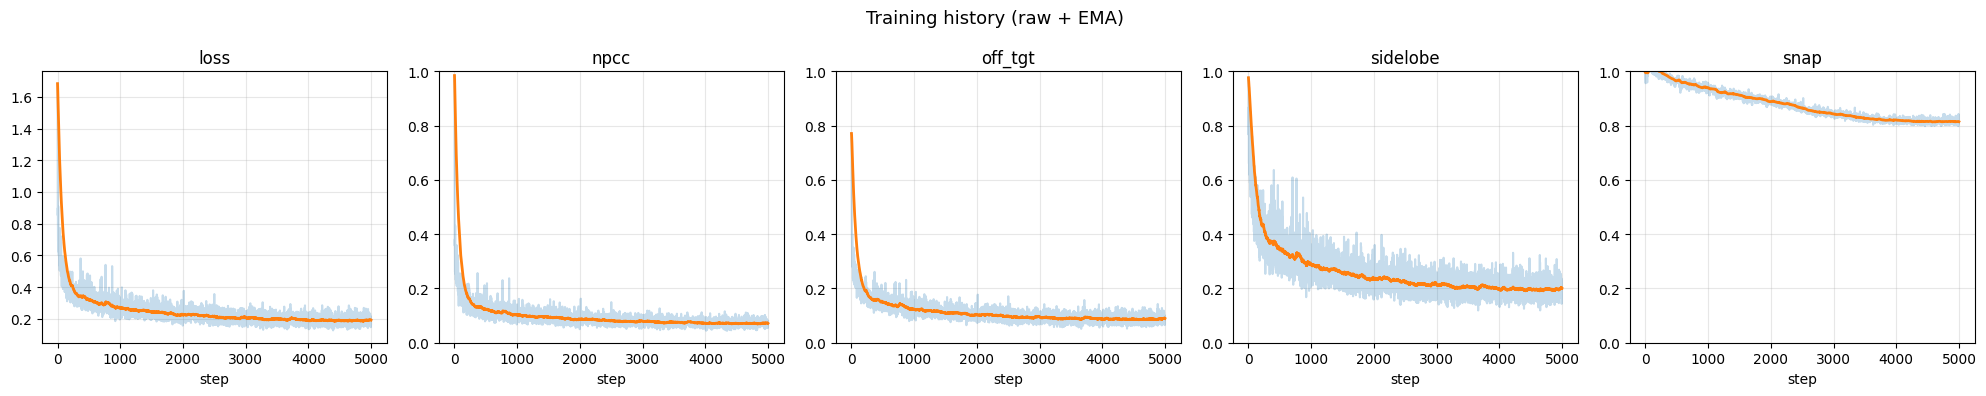

In [16]:
# ── VISUALIZATION: training curves ───────────────────────────────────────────
def exponential_moving_average(series, alpha=0.02):
    smoothed, running = [], series[0]
    for value in series:
        running = (1 - alpha) * running + alpha * value
        smoothed.append(running)
    return smoothed

_curves = [k for k in training_history if training_history[k]]
figure, axes = plt.subplots(1, len(_curves), figsize=(4 * len(_curves), 4))
for axis, key in zip(axes, _curves):
    axis.plot(training_history[key], alpha=0.25)
    axis.plot(exponential_moving_average(training_history[key]), lw=2)
    axis.set_title(key); axis.set_xlabel("step"); axis.grid(alpha=0.3)
    if key != "loss":
        axis.set_ylim(0, 1)
plt.suptitle("Training history (raw + EMA)", fontsize=13)
plt.tight_layout(); plt.show()

## 7. Metrics and one-shot evaluation on the MNIST test set

Metrics: **correlation** (shape fidelity), **PSNR** and **RMSE** (reconstruction error on
peak-normalised maps), and **diffraction efficiency** (fraction of propagated energy inside
the target support). The trained network designs each held-out (energy map, distance) pair
in a single forward pass.

In [17]:
# ── DEFINITIONS: one-shot designer + evaluation metrics ──────────────────────
@torch.no_grad()
def design_phase_profile(target_energy_map, focal_distance_m, quantize=True, num_levels=None):
    """(target [B,1,*,*], distance) → (deployed phase [B,1,N_a,N_a], normalised energy map)."""
    phase_design_network.eval()
    batch = target_energy_map.shape[0]
    distance = (focal_distance_m if torch.is_tensor(focal_distance_m)
                else torch.full((batch,), float(focal_distance_m)))
    distance = distance.to(target_energy_map.device, torch.float32).reshape(batch)
    phase_profile = phase_design_network(target_energy_map, normalize_focal_distance(distance))
    if quantize:
        phase_profile = quantize_phase_profile(phase_profile, num_levels)
    energy_map = energy_map_from_phase_profile(phase_profile, distance)
    energy_map = energy_map / (energy_map.sum((2, 3), keepdim=True) + 1e-9)
    return phase_profile, energy_map


def pearson_correlation(predicted_map, target_map):
    a = predicted_map.ravel() - predicted_map.mean()
    b = target_map.ravel() - target_map.mean()
    return float((a * b).sum() / (np.sqrt((a ** 2).sum() * (b ** 2).sum()) + 1e-12))


def peak_signal_to_noise_ratio(predicted_map, target_map):
    predicted_map = predicted_map / predicted_map.max()
    target_map = target_map / target_map.max()
    mse = np.mean((predicted_map - target_map) ** 2)
    return float(10 * np.log10(1.0 / (mse + 1e-12)))


def root_mean_squared_error(predicted_map, target_map):
    predicted_map = predicted_map / predicted_map.max()
    target_map = target_map / target_map.max()
    return float(np.sqrt(np.mean((predicted_map - target_map) ** 2)))


def diffraction_efficiency(energy_map_tensor, target_tensor):
    """Fraction of propagated energy landing inside the target's bright support."""
    mask = target_support_mask(target_tensor)
    return float(((energy_map_tensor * mask).sum((2, 3))
                  / (energy_map_tensor.sum((2, 3)) + 1e-9)).mean())


# ── Batched (per-image) metrics, so the whole 10,000-image test set is evaluated on GPU ──
def correlation_per_image(predicted_maps, target_maps):
    p = predicted_maps - predicted_maps.mean((2, 3), keepdim=True)
    t = target_maps    - target_maps.mean((2, 3), keepdim=True)
    numerator = (p * t).sum((2, 3))
    denominator = torch.sqrt((p ** 2).sum((2, 3)) * (t ** 2).sum((2, 3)) + 1e-12)
    return (numerator / denominator).reshape(-1)


def psnr_per_image(predicted_maps, target_maps):
    predicted_maps = predicted_maps / (predicted_maps.amax((2, 3), keepdim=True) + 1e-12)
    target_maps = target_maps / (target_maps.amax((2, 3), keepdim=True) + 1e-12)
    mse = ((predicted_maps - target_maps) ** 2).mean((2, 3))
    return (10 * torch.log10(1.0 / (mse + 1e-12))).reshape(-1)


def rmse_per_image(predicted_maps, target_maps):
    predicted_maps = predicted_maps / (predicted_maps.amax((2, 3), keepdim=True) + 1e-12)
    target_maps = target_maps / (target_maps.amax((2, 3), keepdim=True) + 1e-12)
    return torch.sqrt(((predicted_maps - target_maps) ** 2).mean((2, 3))).reshape(-1)


def efficiency_per_image(predicted_maps, target_maps):
    mask = target_support_mask(target_maps)
    return ((predicted_maps * mask).sum((2, 3)) / (predicted_maps.sum((2, 3)) + 1e-9)).reshape(-1)


METRIC_FUNCTIONS = {"correlation": correlation_per_image, "psnr_db": psnr_per_image,
                    "rmse": rmse_per_image, "efficiency": efficiency_per_image}


@torch.no_grad()
def evaluate_designer_on_full_test_set(designer_fn, eval_batch_size):
    """Run a designer over the ENTIRE test set in GPU batches. `designer_fn(targets, distances)`
    must return a normalised energy map [B,1,H,W]. Returns a dict of per-image metric arrays."""
    accumulated = {name: [] for name in METRIC_FUNCTIONS}
    num_images = len(TEST_ENERGY_MAPS)
    for start in range(0, num_images, eval_batch_size):
        stop = min(start + eval_batch_size, num_images)
        targets = torch.from_numpy(TEST_ENERGY_MAPS[start:stop][:, None]).to(CONFIG.device)
        distances = torch.from_numpy(TEST_FOCAL_DISTANCES[start:stop]).to(CONFIG.device)
        predicted_maps = designer_fn(targets, distances)
        for name, metric_fn in METRIC_FUNCTIONS.items():
            accumulated[name].append(metric_fn(predicted_maps, targets).cpu().numpy())
    return {name: np.concatenate(values) for name, values in accumulated.items()}


def summarize_metrics(per_image_metrics):
    return {name: float(np.mean(values)) for name, values in per_image_metrics.items()}

In [18]:
# ── EXECUTION: one-shot design over the ENTIRE 10,000-image MNIST test set ───
EVAL_BATCH_SIZE = 256


def network_designer(targets, distances):
    return design_phase_profile(targets, distances)[1]     # normalised energy map


_nn_start = time.perf_counter()
network_test_metrics = evaluate_designer_on_full_test_set(network_designer, EVAL_BATCH_SIZE)
print(f"Evaluated the network on the {len(TEST_ENERGY_MAPS):,} sampled test images "
      f"in {time.perf_counter() - _nn_start:.1f} s")
network_test_summary = summarize_metrics(network_test_metrics)
print(f"  mean correlation : {network_test_summary['correlation']:.3f}")
print(f"  mean PSNR (dB)   : {network_test_summary['psnr_db']:.2f}")
print(f"  mean RMSE        : {network_test_summary['rmse']:.4f}")
print(f"  mean efficiency  : {network_test_summary['efficiency']:.3f}")

Evaluated the network on the 500 sampled test images in 0.3 s
  mean correlation : 0.938
  mean PSNR (dB)   : 18.47
  mean RMSE        : 0.1245
  mean efficiency  : 0.920


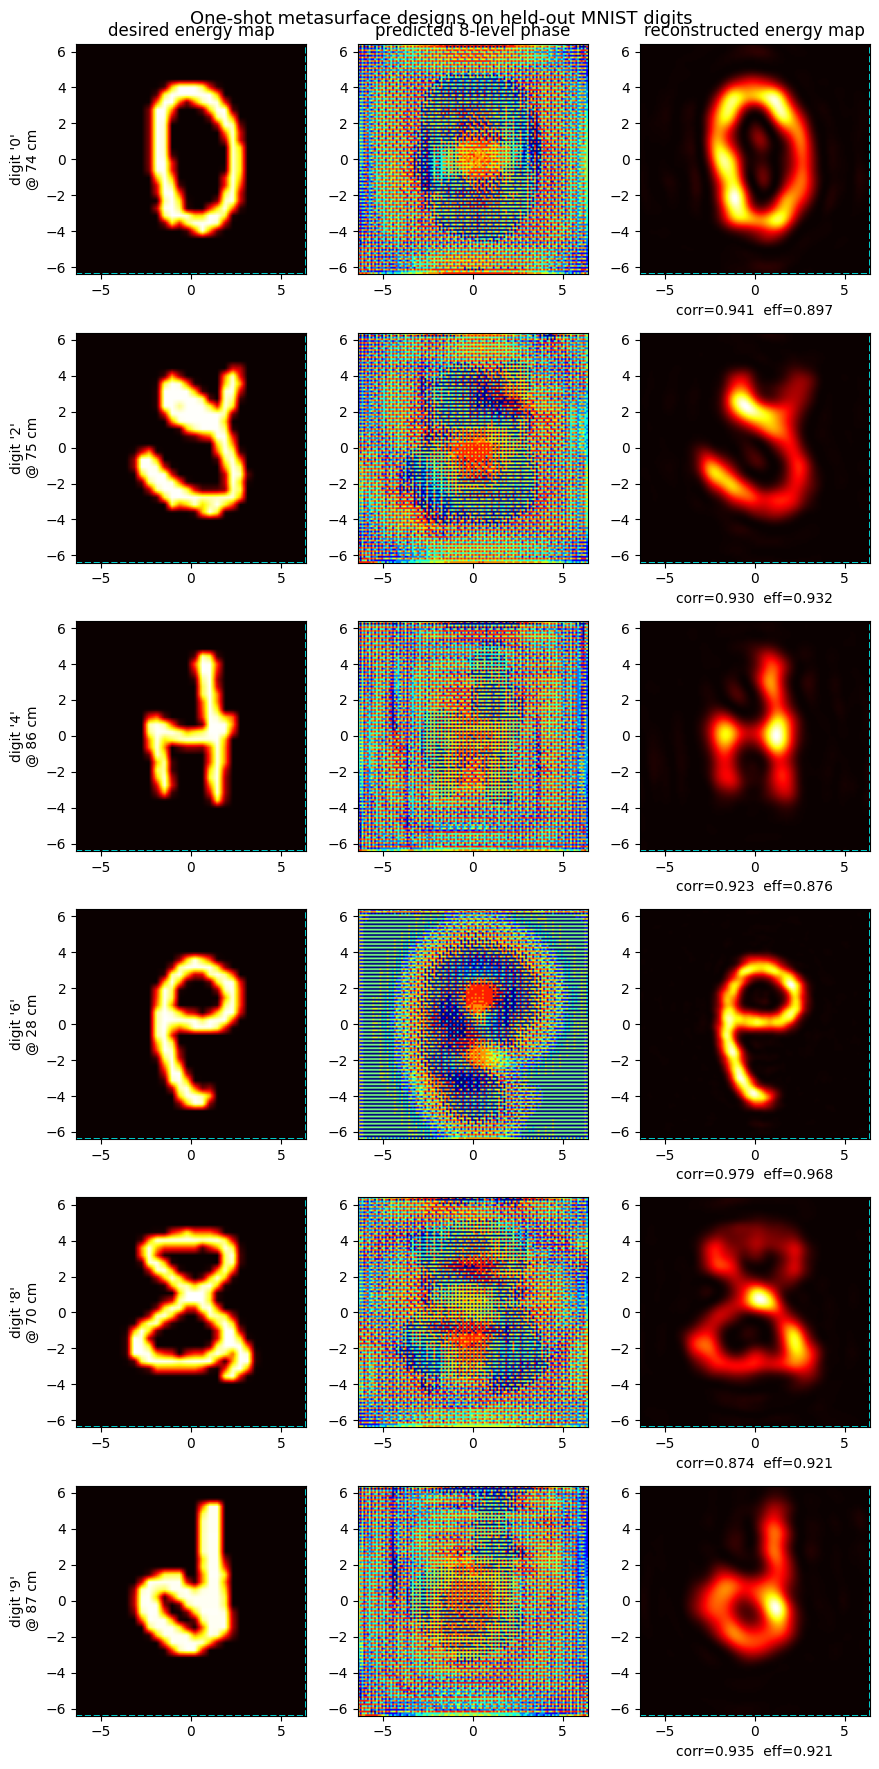

In [19]:
# ── VISUALIZATION: target vs predicted phase vs reconstructed energy map ─────
# One held-out example per selected digit (first test image of each).
EXAMPLE_DIGITS = [0, 2, 4, 6, 8, 9]
example_indices = [int(np.where(TEST_DIGIT_LABELS == d)[0][0]) for d in EXAMPLE_DIGITS]

figure, axes = plt.subplots(len(example_indices), 3,
                            figsize=(9, 3.0 * len(example_indices)), squeeze=False)
for row, index in enumerate(example_indices):
    target_np = TEST_ENERGY_MAPS[index]; distance = float(TEST_FOCAL_DISTANCES[index])
    target_tensor = torch.from_numpy(target_np[None, None]).to(CONFIG.device)
    phase_profile, energy_map = design_phase_profile(target_tensor, distance)
    phase_np = phase_profile.squeeze().cpu().numpy()
    reconstruction_np = energy_map.squeeze().cpu().numpy()
    axes[row, 0].imshow(target_np, cmap="hot", extent=_observation_extent_cm, origin="lower")
    axes[row, 0].set_ylabel(f"digit '{TEST_DIGIT_LABELS[index]}'\n@ {distance*100:.0f} cm")
    draw_aperture_outline(axes[row, 0])
    axes[row, 1].imshow(phase_np, cmap="jet", extent=_aperture_extent_cm, origin="lower",
                        vmin=-np.pi, vmax=np.pi)
    axes[row, 2].imshow(reconstruction_np, cmap="hot", extent=_observation_extent_cm, origin="lower")
    draw_aperture_outline(axes[row, 2])
    if row == 0:
        axes[row, 0].set_title("desired energy map")
        axes[row, 1].set_title(f"predicted {CONFIG.num_discrete_phase_levels}-level phase")
        axes[row, 2].set_title("reconstructed energy map")
    axes[row, 2].set_xlabel(f"corr={pearson_correlation(reconstruction_np, target_np):.3f}  "
                            f"eff={diffraction_efficiency(energy_map, target_tensor):.3f}")
plt.suptitle("One-shot metasurface designs on held-out MNIST digits", fontsize=13)
plt.tight_layout(); plt.show()

## 8. Baselines: Gerchberg–Saxton and weighted Gerchberg–Saxton

Both classical solvers use the **same differentiable propagator**, the **same aperture**, and
the **same K-level quantization** as the network, so the comparison is apples-to-apples. Unlike
the network, they re-iterate from scratch for every target. WGS adaptively re-weights the
target-plane amplitude constraint (with clamping + renormalisation for stability).

In [20]:
# ── DEFINITIONS: GS and weighted-GS phase retrieval ──────────────────────────
@torch.no_grad()
def gerchberg_saxton(target_energy_map, focal_distance_m, num_iterations,
                     num_levels=None, quantize=True, return_trace=False):
    """Classical GS on the aperture grid; enforces target amplitude at the observation plane.
    Fully batched (target [B,1,N,N], distance a float or [B] tensor). `return_trace` records the
    per-iteration correlation (single-image only) and is left off for fast batched evaluation.
    Returns (phase profile [B,1,N_a,N_a], per-iteration correlation trace)."""
    target_amplitude = torch.sqrt(target_energy_map)
    phase_profile = 2 * np.pi * torch.rand(target_energy_map.shape[0], 1,
                                           CONFIG.aperture_grid_size, CONFIG.aperture_grid_size,
                                           device=target_energy_map.device)
    target_np = target_energy_map.squeeze().cpu().numpy() if return_trace else None
    correlation_trace = []
    for _ in range(num_iterations):
        deployed_phase = quantize_phase_profile(phase_profile, num_levels) if quantize else phase_profile
        observed_field = angular_spectrum_propagate(
            complex_exp_from_phase(deployed_phase), focal_distance_m,
            CONFIG.element_pitch_m, CONFIG.wavelength_m, CONFIG.asm_zero_pad_factor,
            output_grid_size=CONFIG.observation_grid_size)
        if return_trace:
            correlation_trace.append(pearson_correlation(
                intensity_of_field(observed_field).squeeze().cpu().numpy(), target_np))
        constrained = target_amplitude.to(torch.complex64) * complex_exp_from_phase(torch.angle(observed_field))
        back_field = angular_spectrum_propagate(
            constrained, -focal_distance_m, CONFIG.element_pitch_m, CONFIG.wavelength_m,
            CONFIG.asm_zero_pad_factor, output_grid_size=CONFIG.aperture_grid_size)
        phase_profile = torch.angle(back_field)
    final_phase = quantize_phase_profile(phase_profile, num_levels) if quantize else phase_profile
    return final_phase, correlation_trace


@torch.no_grad()
def weighted_gerchberg_saxton(target_energy_map, focal_distance_m, num_iterations,
                              num_levels=None, quantize=True, ratio_clamp=(0.5, 2.0),
                              return_trace=False):
    """Weighted (adaptive-additive) GS. The target-plane amplitude is an adaptively updated
    weight; the per-pixel update ratio is clamped and the weight energy is re-anchored each
    iteration to prevent divergence at interference nulls. Fully batched; `return_trace`
    (single-image only) records the per-iteration correlation."""
    target_amplitude = torch.sqrt(target_energy_map)
    support_mask = target_support_mask(target_energy_map)
    support_energy = (target_amplitude * support_mask).sum((2, 3), keepdim=True)
    weight = target_amplitude.clone()
    phase_profile = 2 * np.pi * torch.rand(target_energy_map.shape[0], 1,
                                           CONFIG.aperture_grid_size, CONFIG.aperture_grid_size,
                                           device=target_energy_map.device)
    target_np = target_energy_map.squeeze().cpu().numpy() if return_trace else None
    correlation_trace = []
    for _ in range(num_iterations):
        deployed_phase = quantize_phase_profile(phase_profile, num_levels) if quantize else phase_profile
        observed_field = angular_spectrum_propagate(
            complex_exp_from_phase(deployed_phase), focal_distance_m,
            CONFIG.element_pitch_m, CONFIG.wavelength_m, CONFIG.asm_zero_pad_factor,
            output_grid_size=CONFIG.observation_grid_size)
        if return_trace:
            correlation_trace.append(pearson_correlation(
                intensity_of_field(observed_field).squeeze().cpu().numpy(), target_np))
        achieved_amplitude = observed_field.abs()
        scale = support_energy / ((achieved_amplitude * support_mask).sum((2, 3), keepdim=True) + 1e-9)
        ratio = (target_amplitude / (achieved_amplitude * scale + 1e-9)).clamp(*ratio_clamp)
        weight = torch.where(support_mask.bool(), weight * ratio, weight)
        weight = weight * support_energy / ((weight * support_mask).sum((2, 3), keepdim=True) + 1e-9)
        weight = torch.nan_to_num(weight, nan=0.0, posinf=0.0, neginf=0.0)
        constrained = weight.to(torch.complex64) * complex_exp_from_phase(torch.angle(observed_field))
        back_field = angular_spectrum_propagate(
            constrained, -focal_distance_m, CONFIG.element_pitch_m, CONFIG.wavelength_m,
            CONFIG.asm_zero_pad_factor, output_grid_size=CONFIG.aperture_grid_size)
        phase_profile = torch.angle(back_field)
    final_phase = quantize_phase_profile(phase_profile, num_levels) if quantize else phase_profile
    return final_phase, correlation_trace


@torch.no_grad()
def energy_map_from_baseline_phase(phase_profile, focal_distance_m):
    """Normalised energy map produced by a baseline phase profile."""
    energy_map = energy_map_from_phase_profile(phase_profile, focal_distance_m)
    return energy_map / (energy_map.sum((2, 3), keepdim=True) + 1e-9)

In [21]:
# ── EXECUTION: run GS and WGS over the ENTIRE test set (NN already evaluated) ─
GS_ITERATIONS = 500


def gs_designer(targets, distances):
    phase, _ = gerchberg_saxton(targets, distances, GS_ITERATIONS,
                                num_levels=CONFIG.num_discrete_phase_levels)
    return energy_map_from_baseline_phase(phase, distances)


def wgs_designer(targets, distances):
    phase, _ = weighted_gerchberg_saxton(targets, distances, GS_ITERATIONS,
                                         num_levels=CONFIG.num_discrete_phase_levels)
    return energy_map_from_baseline_phase(phase, distances)


test_metrics_by_method = {"NN": network_test_metrics}     # NN metrics from Section 7
for method_name, designer_fn in [("GS", gs_designer), ("WGS", wgs_designer)]:
    _start = time.perf_counter()
    test_metrics_by_method[method_name] = evaluate_designer_on_full_test_set(designer_fn, EVAL_BATCH_SIZE)
    print(f"{method_name} ({GS_ITERATIONS} it) over all {len(TEST_ENERGY_MAPS):,} test images: "
          f"{time.perf_counter() - _start:.1f} s")

test_summary_by_method = {m: summarize_metrics(v) for m, v in test_metrics_by_method.items()}

print(f"\nMean over all {len(TEST_ENERGY_MAPS):,} held-out MNIST-test images:")
for metric in ["correlation", "psnr_db", "rmse", "efficiency"]:
    print(f"  {metric:12s} — NN {test_summary_by_method['NN'][metric]:.3f}   "
          f"GS {test_summary_by_method['GS'][metric]:.3f}   "
          f"WGS {test_summary_by_method['WGS'][metric]:.3f}")

GS (500 it) over all 500 test images: 7.2 s


WGS (500 it) over all 500 test images: 7.4 s

Mean over all 500 held-out MNIST-test images:
  correlation  — NN 0.938   GS 0.894   WGS 0.894
  psnr_db      — NN 18.473   GS 15.914   WGS 16.849
  rmse         — NN 0.125   GS 0.165   WGS 0.156
  efficiency   — NN 0.920   GS 0.908   WGS 0.847


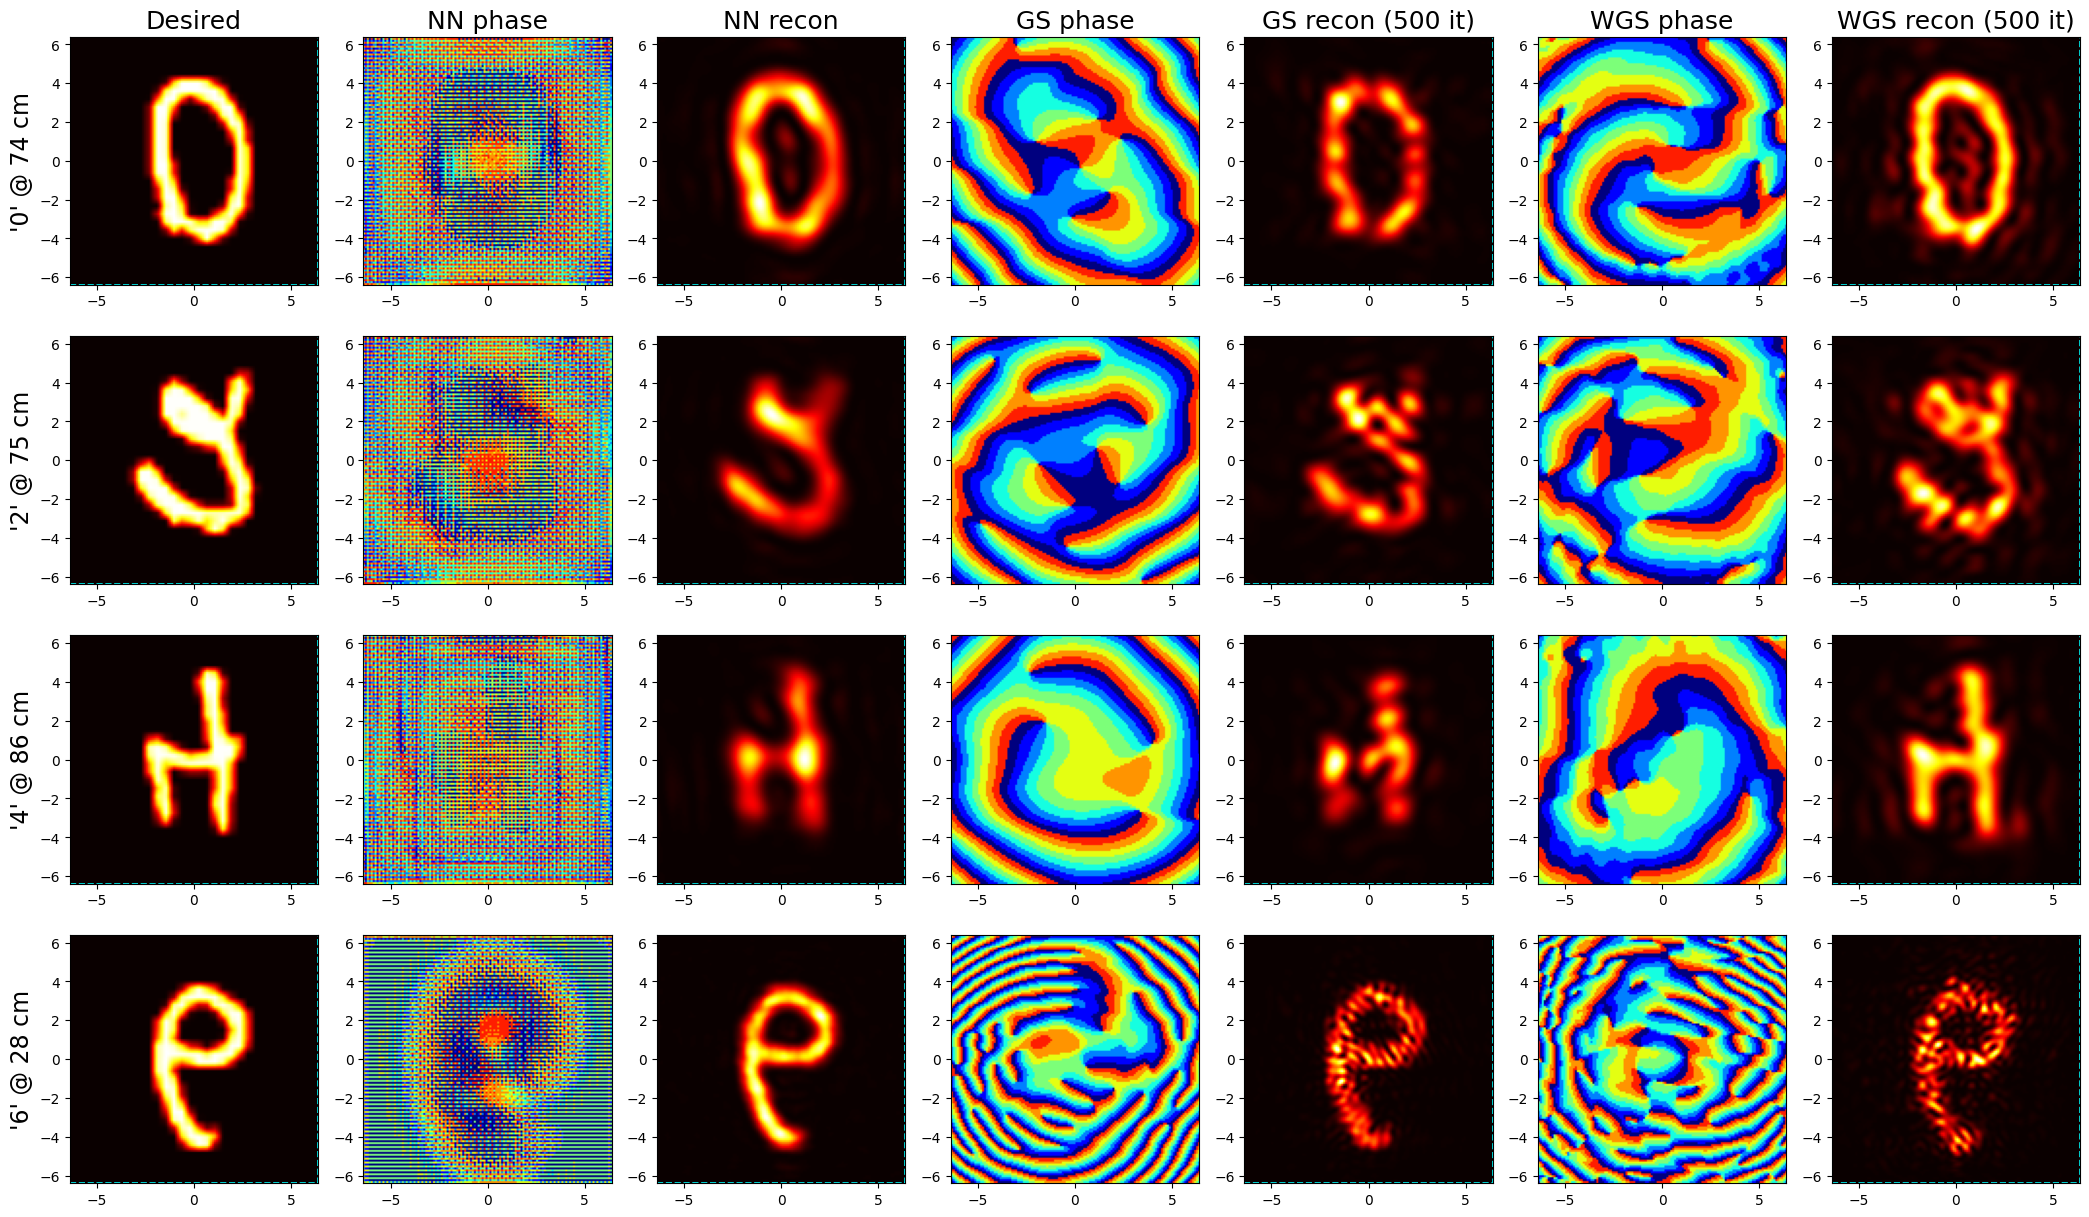

In [22]:
# ── VISUALIZATION: qualitative NN vs GS vs WGS on example digits ─────────────
# Design a handful of held-out digits with all three methods (batched, one call each).
_qual_indices = example_indices[:4]
_qual_targets = torch.from_numpy(TEST_ENERGY_MAPS[_qual_indices][:, None]).to(CONFIG.device)
_qual_distances = torch.from_numpy(TEST_FOCAL_DISTANCES[_qual_indices]).to(CONFIG.device)

_nn_phase, _nn_map = design_phase_profile(_qual_targets, _qual_distances)
_gs_phase, _  = gerchberg_saxton(_qual_targets, _qual_distances, GS_ITERATIONS,
                                 num_levels=CONFIG.num_discrete_phase_levels)
_wgs_phase, _ = weighted_gerchberg_saxton(_qual_targets, _qual_distances, GS_ITERATIONS,
                                          num_levels=CONFIG.num_discrete_phase_levels)
_qual_phase = {"NN": _nn_phase, "GS": _gs_phase, "WGS": _wgs_phase}
_qual_recon = {"NN": _nn_map,
               "GS":  energy_map_from_baseline_phase(_gs_phase, _qual_distances),
               "WGS": energy_map_from_baseline_phase(_wgs_phase, _qual_distances)}

_column_specs = [
    ("target", None,  "Desired"),
    ("NN",  "phase",  "NN phase"),   
    ("NN",  "recon", "NN recon"),
    ("GS",  "phase",  "GS phase"),   
    ("GS",  "recon",  f"GS recon ({GS_ITERATIONS} it)"),
    ("WGS", "phase", "WGS phase"),
    ("WGS", "recon",  f"WGS recon ({GS_ITERATIONS} it)"),
]
figure, axes = plt.subplots(len(_qual_indices), 7, figsize=(21, 3.1 * len(_qual_indices)), squeeze=False)
for row, index in enumerate(_qual_indices):
    target_np = TEST_ENERGY_MAPS[index]
    for col, (method, kind, title) in enumerate(_column_specs):
        axis = axes[row, col]
        if method == "target":
            axis.imshow(target_np, cmap="hot", extent=_observation_extent_cm, origin="lower")
            draw_aperture_outline(axis)
        elif kind == "phase":
            axis.imshow(_qual_phase[method][row].squeeze().cpu().numpy(), cmap="jet",
                        extent=_aperture_extent_cm, origin="lower", vmin=-np.pi, vmax=np.pi)
        else:
            recon = _qual_recon[method][row].squeeze().cpu().numpy()
            axis.imshow(recon, cmap="hot", extent=_observation_extent_cm, origin="lower")
            draw_aperture_outline(axis)
            title = f"{title}"
        if row == 0:
            axis.set_title(title, fontsize=18)
    axes[row, 0].set_ylabel(f"'{TEST_DIGIT_LABELS[index]}' @ {TEST_FOCAL_DISTANCES[index]*100:.0f} cm", fontsize=17)
# plt.suptitle("Neural one-shot design vs Gerchberg–Saxton vs weighted GS (held-out MNIST)", fontsize=13)
plt.tight_layout(); plt.show()

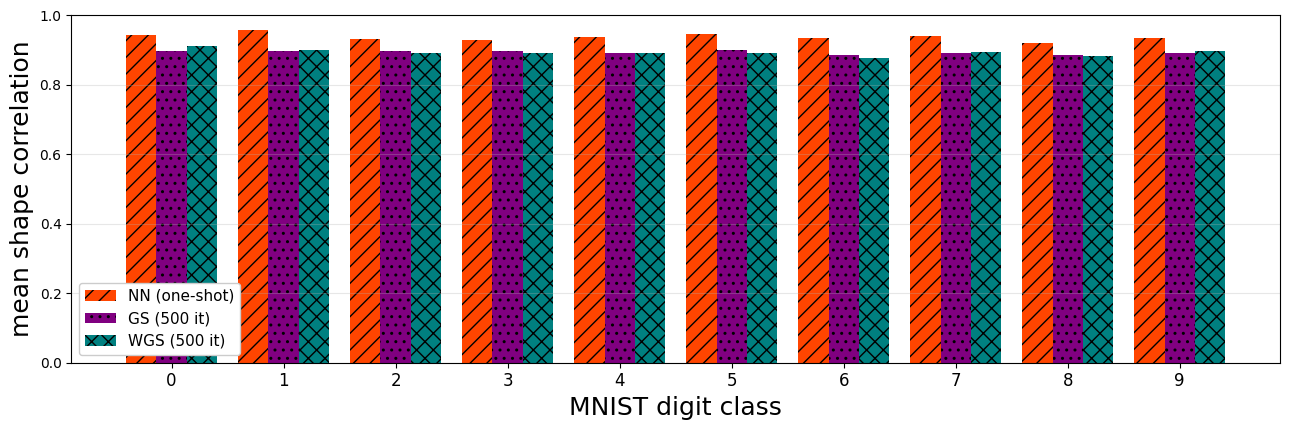

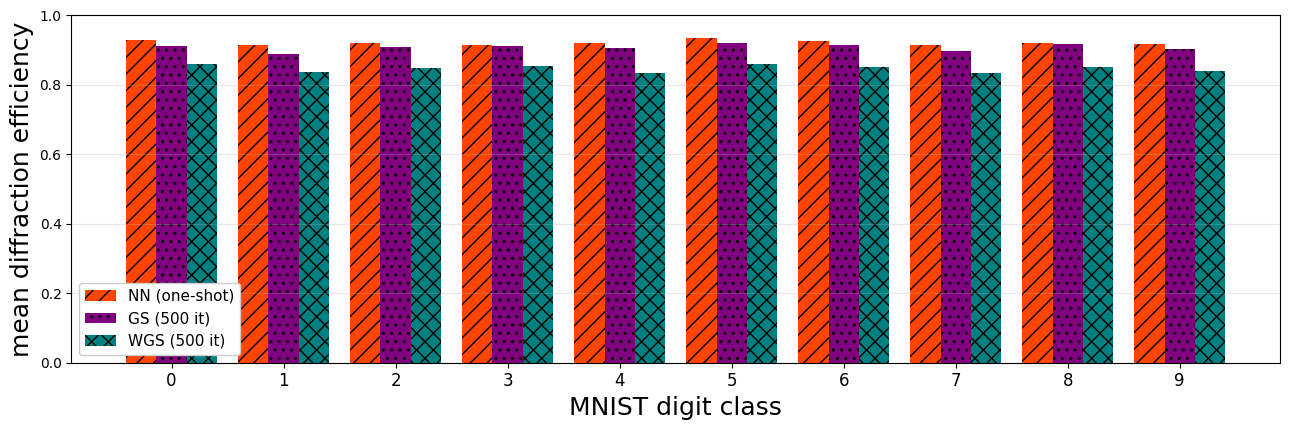

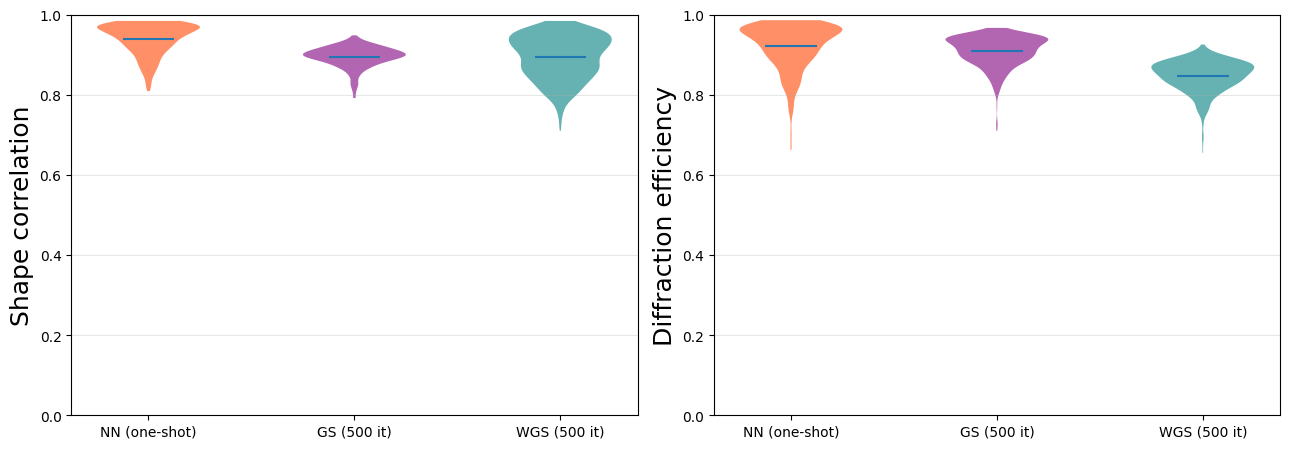

In [64]:
# ── VISUALIZATION: per-digit-class means and full-set distributions ──────────
METHOD_STYLE = {"NN": ("NN (one-shot)", "orangered", "//"),
                "GS": (f"GS ({GS_ITERATIONS} it)", "purple", ".."),
                "WGS": (f"WGS ({GS_ITERATIONS} it)", "teal", "xx")}
_digits = np.arange(10)
_x = np.arange(10); _w = 0.27

# (a) mean metric per digit class (0–9), grouped by method
for metric, ylabel in [("correlation", "Shape correlation"), ("efficiency", "Diffraction efficiency")]:
    figure, axis = plt.subplots(1, 1, figsize=(13, 4.4))
    for offset, method in zip((-_w, 0, _w), ["NN", "GS", "WGS"]):
        per_digit_mean = [test_metrics_by_method[method][metric][TEST_DIGIT_LABELS == d].mean()
                          for d in _digits]
        label, color, hatch = METHOD_STYLE[method]
        axis.bar(_x + offset, per_digit_mean, _w, label=label, color=color, hatch=hatch)
    axis.set_xticks(_x); axis.set_xticklabels([str(d) for d in _digits], fontsize=12)
    axis.set_xlabel("MNIST digit class", fontsize=18)
    axis.set_ylabel(f"mean {ylabel.lower()}", fontsize=18); axis.set_ylim(0, 1)
    axis.grid(alpha=0.3, axis="y"); axis.legend(loc="lower left", fontsize=11, framealpha=1.0)
    # axis.set_title(f"Mean {ylabel.lower()} per digit class (all {len(TEST_ENERGY_MAPS):,} test images)", fontsize=12)
    plt.tight_layout(); plt.show()

# (b) full-set distribution of each metric across all 10,000 designs (violin per method)
figure, axes = plt.subplots(1, 2, figsize=(13, 4.6))
for axis, (metric, ylabel) in zip(axes, [("correlation", "Shape correlation"),
                                         ("efficiency", "Diffraction efficiency")]):
    data = [test_metrics_by_method[m][metric] for m in ["NN", "GS", "WGS"]]
    parts = axis.violinplot(data, showmeans=True, showextrema=False)
    for body, method in zip(parts["bodies"], ["NN", "GS", "WGS"]):
        body.set_facecolor(METHOD_STYLE[method][1]); body.set_alpha(0.6)
    axis.set_xticks([1, 2, 3]); axis.set_xticklabels([METHOD_STYLE[m][0] for m in ["NN", "GS", "WGS"]],
                                                     fontsize=10)
    axis.set_ylabel(ylabel, fontsize=18); axis.set_ylim(0, 1); axis.grid(alpha=0.3, axis="y")
    # axis.set_title(f"{ylabel} distribution over all {len(TEST_ENERGY_MAPS):,} designs", fontsize=11)
plt.tight_layout(); plt.show()

## 9. Runtime vs quality

The network designs a target in a single forward pass; GS/WGS pay a per-iteration cost for
every design. Timing and quality are measured in separate passes so metric/CPU-transfer
overhead never inflates the runtime axis. GS/WGS quality traces are averaged over several
random initialisations.

In [24]:
# ── DEFINITIONS: CUDA sync + timing/quality-trace helpers ────────────────────
def synchronize_device():
    if CONFIG.device == "cuda":
        torch.cuda.synchronize()


def time_callable_ms(callable_fn, num_timed_runs):
    synchronize_device(); start = time.perf_counter()
    for _ in range(num_timed_runs):
        callable_fn()
    synchronize_device()
    return (time.perf_counter() - start) / num_timed_runs * 1000


def average_correlation_trace(retrieval_fn, target_tensor, distance, num_iterations, num_traces):
    """Average a solver's per-iteration correlation trace over several random inits
    (GS/WGS start from random phase, so a single trace is noisy)."""
    traces = []
    for _ in range(num_traces):
        _, correlation_trace = retrieval_fn(target_tensor, distance, num_iterations,
                                            num_levels=CONFIG.num_discrete_phase_levels,
                                            return_trace=True)
        traces.append(correlation_trace)
    return np.mean(traces, axis=0)

In [25]:
# ── EXECUTION: measure per-iteration quality traces and wall-clock timing ────
TEST_INDEX = 0
TIMING_WARMUP_RUNS = 10
TIMING_TIMED_RUNS  = 20
NUM_QUALITY_TRACES = 3

_bench_index = int(example_indices[TEST_INDEX])
_bench_digit = int(TEST_DIGIT_LABELS[_bench_index])
_bench_target_np = TEST_ENERGY_MAPS[_bench_index]
_bench_distance = float(TEST_FOCAL_DISTANCES[_bench_index])
_bench_target = torch.from_numpy(_bench_target_np[None, None]).to(CONFIG.device)

# per-iteration correlation traces (averaged over random inits)
gs_correlation_trace  = average_correlation_trace(gerchberg_saxton, _bench_target,
                                                  _bench_distance, GS_ITERATIONS, NUM_QUALITY_TRACES)
wgs_correlation_trace = average_correlation_trace(weighted_gerchberg_saxton, _bench_target,
                                                  _bench_distance, GS_ITERATIONS, NUM_QUALITY_TRACES)

# timing (separate low-overhead passes)
for _ in range(TIMING_WARMUP_RUNS):
    design_phase_profile(_bench_target, _bench_distance)
    gerchberg_saxton(_bench_target, _bench_distance, 1, num_levels=CONFIG.num_discrete_phase_levels)
    weighted_gerchberg_saxton(_bench_target, _bench_distance, 1, num_levels=CONFIG.num_discrete_phase_levels)
synchronize_device()

network_inference_ms = time_callable_ms(
    lambda: design_phase_profile(_bench_target, _bench_distance), TIMING_TIMED_RUNS)
gs_per_iteration_ms = time_callable_ms(
    lambda: gerchberg_saxton(_bench_target, _bench_distance, GS_ITERATIONS,
                             num_levels=CONFIG.num_discrete_phase_levels), TIMING_TIMED_RUNS) / GS_ITERATIONS
wgs_per_iteration_ms = time_callable_ms(
    lambda: weighted_gerchberg_saxton(_bench_target, _bench_distance, GS_ITERATIONS,
                                      num_levels=CONFIG.num_discrete_phase_levels), TIMING_TIMED_RUNS) / GS_ITERATIONS

gs_cumulative_ms  = np.arange(1, GS_ITERATIONS + 1) * gs_per_iteration_ms
wgs_cumulative_ms = np.arange(1, GS_ITERATIONS + 1) * wgs_per_iteration_ms

_nn_phase, _nn_map = design_phase_profile(_bench_target, _bench_distance)
network_benchmark_correlation = pearson_correlation(_nn_map.squeeze().cpu().numpy(), _bench_target_np)

print(f"Benchmark target: digit '{_bench_digit}' @ {_bench_distance*100:.0f} cm, "
      f"K={CONFIG.num_discrete_phase_levels}")
print(f"  NN one-shot : {network_inference_ms:8.3f} ms   (corr {network_benchmark_correlation:.3f})")
print(f"  GS  total   : {gs_cumulative_ms[-1]:8.1f} ms   ({gs_per_iteration_ms:.3f} ms/it × {GS_ITERATIONS}, "
      f"corr {gs_correlation_trace[-1]:.3f})")
print(f"  WGS total   : {wgs_cumulative_ms[-1]:8.1f} ms   ({wgs_per_iteration_ms:.3f} ms/it × {GS_ITERATIONS}, "
      f"corr {wgs_correlation_trace[-1]:.3f})")
print(f"  Speed-up    : NN is {gs_cumulative_ms[-1]/network_inference_ms:,.0f}× faster than "
      f"GS at {GS_ITERATIONS} iterations")

Benchmark target: digit '0' @ 74 cm, K=8
  NN one-shot :    2.115 ms   (corr 0.941)
  GS  total   :    247.8 ms   (0.496 ms/it × 500, corr 0.913)
  WGS total   :    309.8 ms   (0.620 ms/it × 500, corr 0.942)
  Speed-up    : NN is 117× faster than GS at 500 iterations


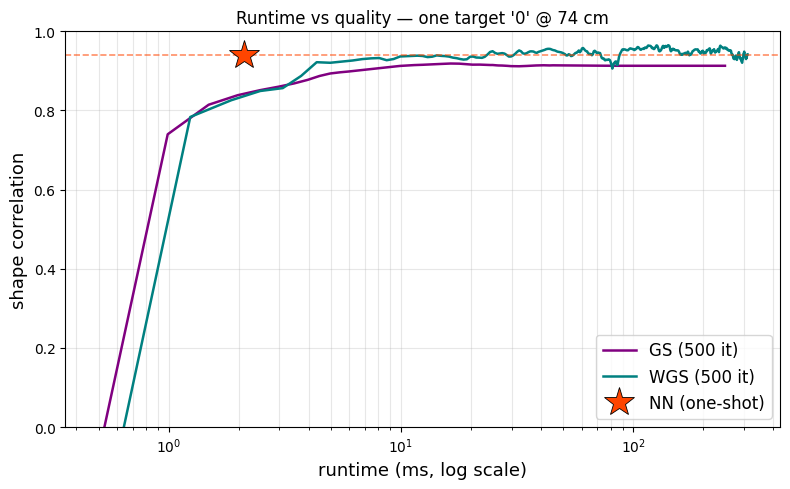

In [26]:
# ── VISUALIZATION: runtime vs quality ────────────────────────────────────────
figure, axis = plt.subplots(1, 1, figsize=(8, 5))
axis.plot(gs_cumulative_ms,  gs_correlation_trace,  "-", color="purple", lw=1.8,
          label=f"GS ({GS_ITERATIONS} it)")
axis.plot(wgs_cumulative_ms, wgs_correlation_trace, "-", color="teal", lw=1.8,
          label=f"WGS ({GS_ITERATIONS} it)")
axis.plot(network_inference_ms, network_benchmark_correlation, "*", color="orangered",
          ms=22, mec="black", mew=0.6, zorder=5, label="NN (one-shot)")
axis.axhline(network_benchmark_correlation, color="orangered", ls="--", lw=1.2, alpha=0.6)
axis.set_xscale("log")
axis.set_xlabel("runtime (ms, log scale)", fontsize=13)
axis.set_ylabel("shape correlation", fontsize=13)
axis.set_ylim(0, 1); axis.grid(alpha=0.3, which="both")
axis.legend(loc="lower right", fontsize=12)
axis.set_title(f"Runtime vs quality — one target '{_bench_digit}' "
               f"@ {_bench_distance*100:.0f} cm", fontsize=12)
plt.tight_layout(); plt.show()

## 10. Summary

Aggregated metrics and per-design runtime for all three methods over the seed-sampled held-out MNIST test set. The neural designer produces every profile in a single forward pass; the iterative
baselines pay their full per-target iteration cost for each design.

In [27]:
# ── EXECUTION + PRINT: final summary table ───────────────────────────────────
_per_design_runtime_ms = {
    "NN":  network_inference_ms,
    "GS":  gs_per_iteration_ms  * GS_ITERATIONS,
    "WGS": wgs_per_iteration_ms * GS_ITERATIONS,
}
_method_labels = {"NN": "NN (one-shot)",
                  "GS": f"GS ({GS_ITERATIONS} it)",
                  "WGS": f"WGS ({GS_ITERATIONS} it)"}

_header = f"{'method':<16}{'corr':>8}{'PSNR(dB)':>10}{'RMSE':>9}{'efficiency':>12}{'time/design':>14}"
print(_header); print("-" * len(_header))
for method in ["NN", "GS", "WGS"]:
    summary = test_summary_by_method[method]
    print(f"{_method_labels[method]:<16}"
          f"{summary['correlation']:>8.3f}"
          f"{summary['psnr_db']:>10.2f}"
          f"{summary['rmse']:>9.4f}"
          f"{summary['efficiency']:>12.3f}"
          f"{_per_design_runtime_ms[method]:>11.2f} ms")
print("-" * len(_header))
print(f"Held-out set: {len(TEST_ENERGY_MAPS):,} seed-sampled MNIST-test images. "
      f"NN is {_per_design_runtime_ms['GS']/_per_design_runtime_ms['NN']:,.0f}× faster than GS "
      f"and {_per_design_runtime_ms['WGS']/_per_design_runtime_ms['NN']:,.0f}× faster than WGS "
      f"per design, at comparable shape fidelity.")

method              corr  PSNR(dB)     RMSE  efficiency   time/design
---------------------------------------------------------------------
NN (one-shot)      0.938     18.47   0.1245       0.920       2.11 ms
GS (500 it)        0.894     15.91   0.1654       0.908     247.78 ms
WGS (500 it)       0.894     16.85   0.1561       0.847     309.81 ms
---------------------------------------------------------------------
Held-out set: 500 seed-sampled MNIST-test images. NN is 117× faster than GS and 147× faster than WGS per design, at comparable shape fidelity.


## 11. Through-focus response

Design a metasurface for one held-out digit **at its target distance**, then propagate that
single **fixed** phase profile to five distances centred on the design plane (middle = target
distance). The pattern should be sharpest — and most correlated with the target — at the design
plane, and blur/defocus away from it, confirming the network places the image at the requested
distance rather than everywhere at once.

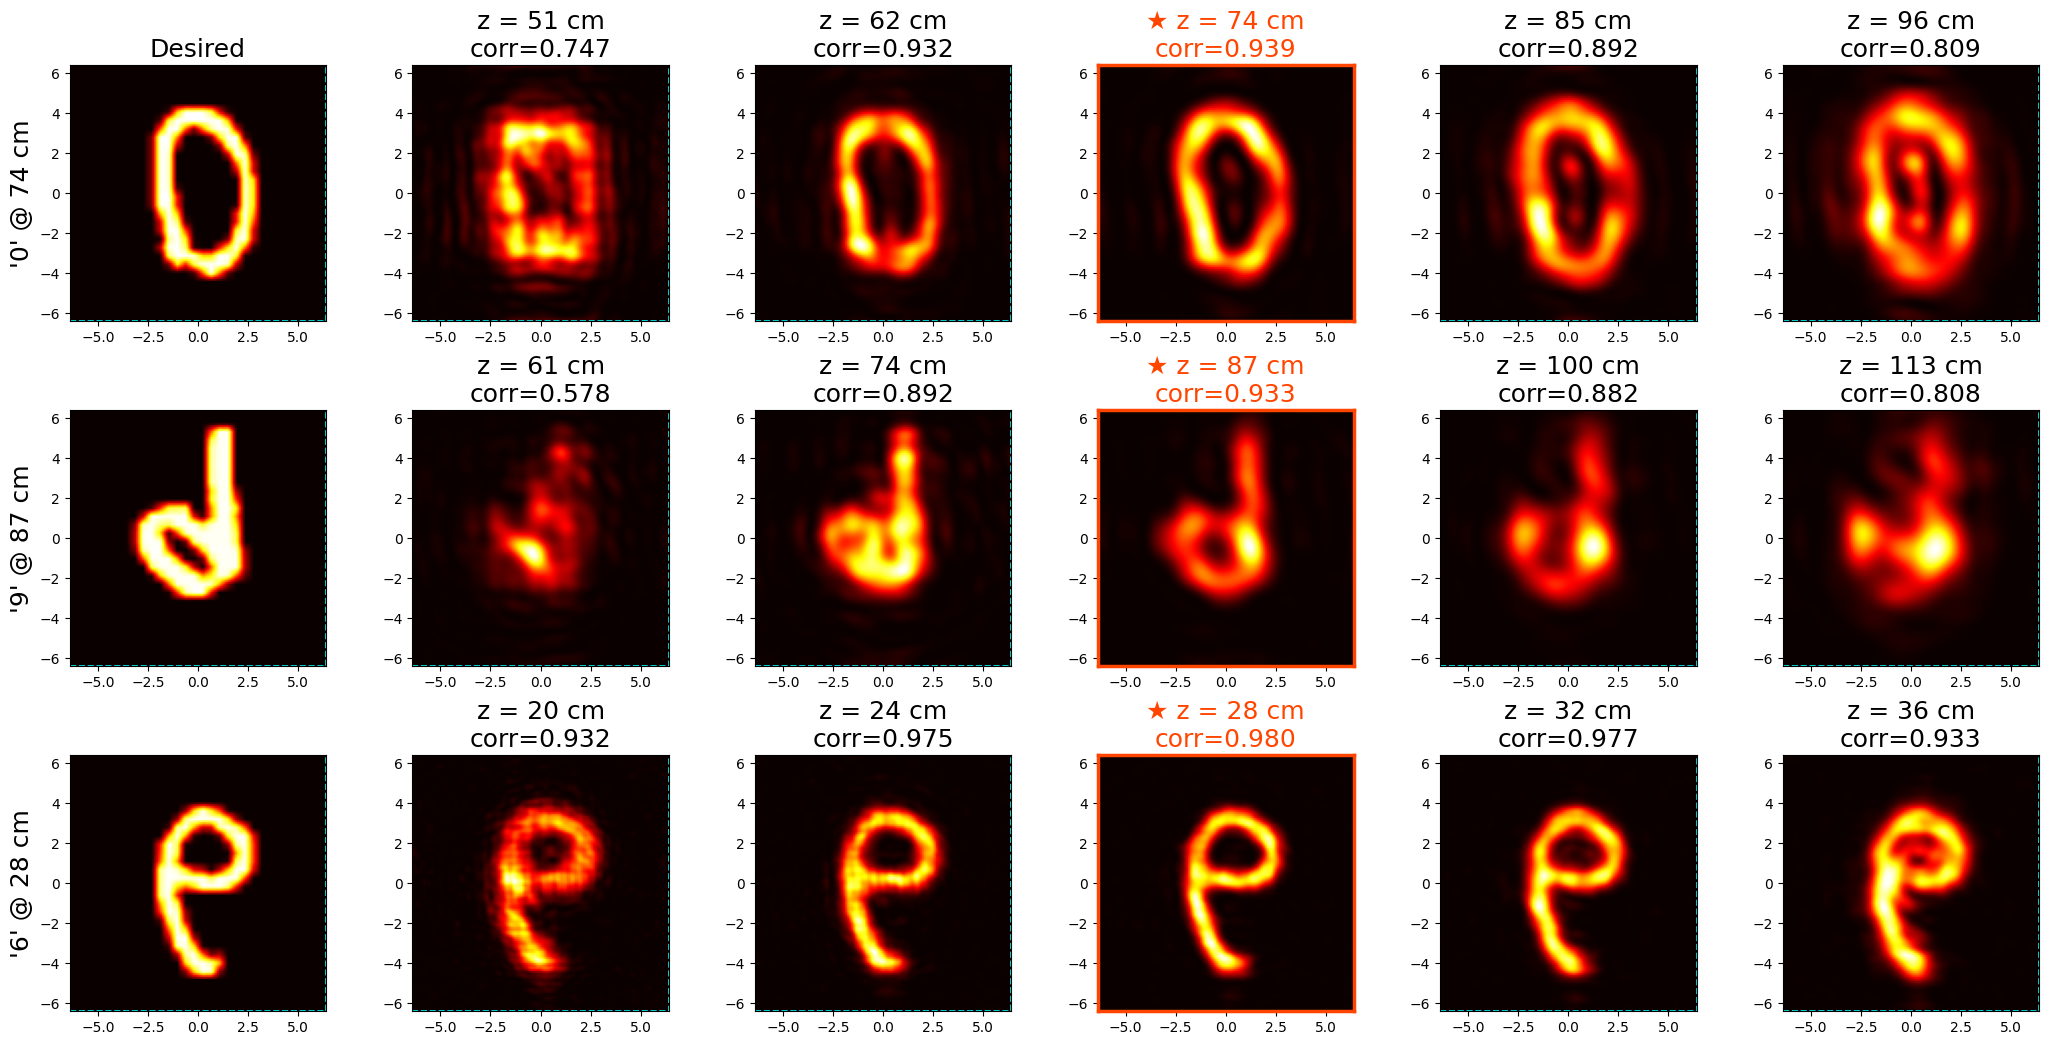

In [62]:
# ── EXECUTION + VISUALIZATION: through-focus response for N examples ──────────
# For each example: design one fixed phase profile at its target distance, then propagate
# that SAME profile to 5 distances centred on the design plane (middle column = target).
NUM_THROUGH_FOCUS_EXAMPLES = 3
through_focus_indices = [int(i) for i in example_indices[:NUM_THROUGH_FOCUS_EXAMPLES]]
through_focus_indices = [
    example_indices[0],
    example_indices[5],
    example_indices[3],
]

DEFOCUS_FRACTION = 0.15
defocus_multipliers = 1 + DEFOCUS_FRACTION * np.arange(-2, 3)   # [0.70, 0.85, 1.00, 1.15, 1.30]

figure, axes = plt.subplots(len(through_focus_indices), 6,
                            figsize=(21, 3.5 * len(through_focus_indices)), squeeze=False)
for row, index in enumerate(through_focus_indices):
    target_np = TEST_ENERGY_MAPS[index]
    design_distance_m = float(TEST_FOCAL_DISTANCES[index])
    target_tensor = torch.from_numpy(target_np[None, None]).to(CONFIG.device)
    phase_profile, _ = design_phase_profile(target_tensor, design_distance_m)   # fixed K-level phase
    evaluation_distances_m = design_distance_m * defocus_multipliers

    axes[row, 0].imshow(target_np, cmap="hot", extent=_observation_extent_cm, origin="lower")
    draw_aperture_outline(axes[row, 0])
    axes[row, 0].set_ylabel(f"'{TEST_DIGIT_LABELS[index]}' @ {design_distance_m*100:.0f} cm", fontsize=18)
    if row == 0:
        axes[row, 0].set_title("Desired", fontsize=18)

    for col, evaluation_distance in enumerate(evaluation_distances_m, start=1):
        energy_map = energy_map_from_phase_profile(phase_profile, float(evaluation_distance))
        energy_map_np = (energy_map / (energy_map.sum() + 1e-9)).squeeze().cpu().numpy()
        correlation = pearson_correlation(energy_map_np, target_np)
        is_design_plane = bool(np.isclose(evaluation_distance, design_distance_m))
        axis = axes[row, col]
        axis.imshow(energy_map_np, cmap="hot", extent=_observation_extent_cm, origin="lower")
        draw_aperture_outline(axis)
        axis.set_title(("\u2605 " if is_design_plane else "")
                       + f"z = {evaluation_distance*100:.0f} cm\ncorr={correlation:.3f}",
                       color="orangered" if is_design_plane else "black", fontsize=18)
        if is_design_plane:
            for spine in axis.spines.values():
                spine.set_color("orangered"); spine.set_linewidth(2.5)

    # if row == len(through_focus_indices) - 1:
    #     for col in range(6):
    #         axes[row, col].set_xlabel("x (cm)")

# plt.suptitle("Through-focus response — each fixed phase profile propagated to five distances ""(middle column = design plane)", fontsize=13)
plt.tight_layout()
plt.show()
